**Import Libraries**

In [1]:
import os
import shutil
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pyspark core
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, StringType, IntegerType
from pyspark.sql.window import Window

# Pyspark ML - preprocessing
from pyspark.ml.feature import (
    VectorAssembler, StandardScaler as SparkScaler,
    StringIndexer, OneHotEncoder
)

# Pyspark ML - models
from pyspark.ml.regression import (
    LinearRegression as SparkLR,
    RandomForestRegressor as SparkRF,
    DecisionTreeRegressor as SparkDT,
    GBTRegressor as SparkGBT
)
from pyspark.ml import Pipeline

# Pyspark ML - tuning and evaluation
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import RegressionEvaluator

**Create Spark Session**

In [2]:
spark = (
    SparkSession.builder \
    .appName("SmartCity_Modeling") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .config("spark.sql.shuffle.partitions", "4") \
    .config("spark.network.timeout", "800s") \
    .config("spark.executor.heartbeatInterval", "80s") \
    .config("spark.python.worker.reuse", "true") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.task.maxFailures", "8") \
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print(f"Spark Version: {spark.version}")
print("Spark session started")

Spark Version: 3.5.0
Spark session started


**Output Directory**

In [3]:
CLEAN_DIR = "clean_data"
MODELS_DIR = "saved_models"
os.makedirs(MODELS_DIR, exist_ok=True)
print(f"Loading clean data from → {CLEAN_DIR}/")
print(f"Saving models to → {MODELS_DIR}/")

Loading clean data from → clean_data/
Saving models to → saved_models/


**Shared Tuning Helpers**

In [4]:
# Shared function to determine fit status based on train, CV, and test R² scores

def fit_status(train_r2, cv_r2, test_r2, gap):
    if train_r2 > 0.9 and (train_r2 - test_r2) > 0.08:
        return "🔴 Overfitting"
    elif train_r2 < 0.75 and test_r2 < 0.75:
        return "🟡 Underfitting"
    elif abs(cv_r2 - test_r2) > 0.05:
        return "🟠 Unstable"
    else:
        return "🟢 Good Fit"

In [5]:
# Shared function to train and evaluate models on Pyspark DataFrames

def train_and_evaluate(sdf_train, sdf_test, feature_cols, target_col, models_def, label, color):
    """
    Build and evaluate all 4 models on Pyspark DataFrames.
    Returns results dict and best model name.
    Predictions are computed on the spark cluster.
    Metrics are evaluated on the collected test predictions
    """
    if "features" in sdf_train.columns:
        sdf_train_vec = sdf_train.select("features", target_col)
        sdf_test_vec  = sdf_test.select("features", target_col)
    else:
        assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")
        sdf_train_vec = assembler.transform(sdf_train).select("features", target_col)
        sdf_test_vec  = assembler.transform(sdf_test).select("features", target_col)
    
    evaluator_rmse = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="rmse")
    evaluator_r2 = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="r2")
    evaluator_mae = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="mae")

    results = {}
    print(f"\n\n{'='*95}")
    print(f" {label} - Model Training and Evaluation")
    print(f"{'='*95}")
    print(f"{'Model':<28} {'RMSE':>10} {'MAE':>10} {'MSE':>14} {'R²':>8} {'Time':>14}")
    print(f"{'-'*95}")

    for name, estimator in models_def.items():
        t0 = time.time()
        pipeline = Pipeline(stages=[estimator])
        fitted = pipeline.fit(sdf_train_vec)
        preds = fitted.transform(sdf_test_vec)

        rmse = evaluator_rmse.evaluate(preds)
        r2 = evaluator_r2.evaluate(preds)
        mae = evaluator_mae.evaluate(preds)
        mse = rmse ** 2

        # Collect test predictions for sklearn metrics and plots
        preds_pd = preds.select(target_col, "prediction").toPandas()

        results[name] = {
            'model': fitted,
            'estimator' : estimator,   # unfitted - used in cv_overfit_check
            'pred' : preds_pd["prediction"].values,
            'preds_pd': preds_pd,
            'RMSE': rmse,
            'MAE': mae,
            'MSE': mse,
            'R2 score': r2
        }

        print(f" {name:<28} {rmse:>10.4f} {mae:>10.4f} {mse:>14.4f} {r2:>8.4f} ({time.time()-t0:.1f}s)")

    best_name = max(results, key=lambda k: results[k]['R2 score'])
    return results, best_name

In [6]:
# Shared function to compute Train R² / CV R² / Test R² for each model and determine fit status

def cv_overfit_check(sdf_train, feature_cols, target_col, results, label):
    """
    Compute Train R² / CV R² / Test R² for each model.
    Uses 3-fold Pyspark Cross Validation
    """
    if "features" in sdf_train.columns:
        sdf_vec = sdf_train.select("features", target_col)
    else:
        assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")
        sdf_vec = assembler.transform(sdf_train).select("features", target_col)
      
    evaluator = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="r2")

    print(f"\n\n{'='*95}")
    print(f"  {label} - OVERFITTING and UNDERFITTING CHECK (Pyspark 3-fold CV)")
    print(f"{'='*95}")
    print(f"{'Model':<28} {'Train R²':>10} {'CV Mean R²':>12} {'Test R²':>10} {'Gap':>10} {'Status':>15}")
    print(f"{'-'*95}")

    cv_results = {}

    for name, res in results.items():
        estimator = res['estimator']

        # Train R²
        train_preds = res['model'].transform(sdf_vec)
        train_r2 = evaluator.evaluate(train_preds)

        # Cross Validator
        paramGrid = ParamGridBuilder().build()  # No hyperparams, just 2-fold CV
        cv = CrossValidator(estimator=estimator, estimatorParamMaps=paramGrid, evaluator=evaluator, numFolds=2, seed=42, parallelism=1)
        cv_model = cv.fit(sdf_vec)

        # CV metrics
        cv_scores = cv_model.avgMetrics
        cv_mean = float(np.mean(cv_scores))

        # Test score
        test_r2 = res["R2 score"]
        gap = train_r2 - test_r2

        # Status
        status = fit_status(train_r2, cv_mean, test_r2, gap)

        cv_results[name] = {
            "train_r2": train_r2,
            "cv_mean": cv_mean,
            "test_r2": test_r2,
            "gap": train_r2 - test_r2,
            "status": status
        }
        print(f"{name:<28} {train_r2:>10.4f} {cv_mean:>12.4f} {test_r2:>10.4f} {gap:>10.4f} {status:>15}")
    
    print("=" * 95)
    print("\\nStatus Guide:")
    print("  🟢 Good Fit    → Train R² ≈ CV R² ≈ Test R²  — model generalizes well")
    print("  🔴 Overfitting → Train R² >> Test R²          — model memorized training data")
    print("  🟡 Underfitting→ Train R² and Test R² both low — model too simple")
    print("  🟠 Unstable    → Large Train–Test Gap          — model sensitive to data splits")
    return cv_results

In [7]:
# Shared function to plot Train R² / CV R² / Test R² bars and Train-Test gap for each model

def plot_cv_bars(cv_results, label, color):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    names = list(cv_results.keys())
    x = np.arange(len(names))
    width = 0.25

    axes[0].bar(x - width, [cv_results[n]["train_r2"] for n in names], width, label='Train R²',
            color=color, alpha=0.85)
    axes[0].bar(x, [cv_results[n]["cv_mean"] for n in names], width, label='CV Mean R²',
            color='darkorange', alpha=0.85)
    axes[0].bar(x + width, [cv_results[n]["test_r2"] for n in names], width, label='Test R²',
            color='tomato', alpha=0.85)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(names, rotation=15)
    axes[0].set_ylabel('R²')
    axes[0].set_ylim(0, 1.1)
    axes[0].set_title(f"{label} — Train vs CV vs Test R²")
    axes[0].legend()
    axes[0].axhline(1.0, color='gray', linestyle='--', lw=0.8, alpha=0.5)

    gaps = [cv_results[n]["gap"] for n in names]
    gap_color = ['tomato' if g > 0.08 else color for g in gaps]
    axes[1].bar(names, gaps, color=gap_color, alpha=0.85)
    axes[1].axhline(0.08, color='red', linestyle='--', lw=1.5,
                label='Overfit threshold (0.08)')
    axes[1].axhline(0.0,  color='green', linestyle='-', lw=1,
                label='Perfect generalization')
    axes[1].set_ylabel('Train R² − Test R²  (Gap)')
    axes[1].set_title(f"{label} — Train-Test Gap (lower is better)")
    axes[1].tick_params(axis='x', rotation=15)
    axes[1].legend()

    plt.suptitle(f"{label} — Overfitting & Underfitting Analysis", fontsize=13)
    plt.tight_layout()
    plt.show()

In [8]:
# Shared function to plot MSE, MAE, RMSE, and R² bars for each model

def plot_metric_bars(results, best_name, suffix, label, color):
    fig, axes = plt.subplots(2,2, figsize=(15, 10))
    names = list(results.keys())
    clrs = ["tomato" if n == best_name else color for n in names]
    
    mk = lambda k: k + suffix
    rs = lambda k: [results[n][k] for n in names]

    axes[0,0].bar(names, rs("MSE"), color=clrs)
    axes[0,0].set_title(f"{label} - MSE{suffix} (lower is better)")
    axes[0,0].set_ylabel(f"MSE{suffix}")
    axes[0,0].tick_params(axis='x', rotation=15)

    axes[0,1].bar(names, rs("MAE"), color=clrs)
    axes[0,1].set_title(f"{label} - MAE{suffix} (lower is better)")
    axes[0,1].set_ylabel(f"MAE{suffix}")
    axes[0,1].tick_params(axis='x', rotation=15)

    axes[1,0].bar(names, rs("RMSE"), color=clrs)
    axes[1,0].set_title(f"{label} - RMSE{suffix} (lower is better)")
    axes[1,0].set_ylabel(f"RMSE{suffix}")
    axes[1,0].tick_params(axis='x', rotation=15)
    
    axes[1,1].bar(names, rs("R2 score"), color=clrs)
    axes[1,1].set_title(f"{label} - R2{suffix} (higher is better)")
    axes[1,1].set_ylabel(f"R2{suffix}")
    axes[1,1].tick_params(axis='x', rotation=15)
    
    plt.suptitle(f"{label} — Model Comparison | Best: {best_name}", fontsize=13)
    plt.tight_layout()
    plt.show()
    

In [9]:
# Shared function to plot actual vs predicted values for the best model

def plot_actual_vs_pred(results, best_name, actual_label, pred_label, color):
    preds_pd = results[best_name]['preds_pd']
    y_actual = preds_pd.iloc[:, 0]
    y_pred = preds_pd["prediction"]
    plt.figure(figsize=(7, 5))
    plt.scatter(y_actual, y_pred, alpha=0.3, s=10, color=color)
    mn = y_actual.min()
    mx = y_actual.max()
    plt.plot([mn, mx], [mn, mx], "r--", lw=2)
    plt.xlabel(actual_label)
    plt.ylabel(pred_label)
    plt.title(f"Actual vs Predicted for {best_name}")
    plt.tight_layout()
    plt.show()

In [10]:
# Shared function to plot residuals for the best model

def plot_residuals(results, best_name, xlabel, color):
    preds_pd = results[best_name]['preds_pd']
    y_actual = preds_pd.iloc[:, 0]
    residuals = y_actual - preds_pd["prediction"]
    plt.figure(figsize=(7, 5))
    plt.scatter(preds_pd["prediction"], residuals, alpha=0.3, s=10, color=color)
    plt.axhline(0, color='red', linestyle='--', lw=2)
    plt.xlabel(xlabel)
    plt.ylabel("Residuals (Actual - Predicted)")
    plt.title(f"Residual Plot ({best_name})")
    plt.tight_layout()
    plt.show()

In [11]:
# Shared function to plot feature importance for the best model

def plot_feature_importance(model, feature_cols, best_name, color, top_n=15):
    # Tree-based models only
    if hasattr(model, "featureImportances"):
        importances = model.featureImportances.toArray()
    else:
        print(f"{best_name} does not support feature importances")
        return
    # Match feature names count safely
    if len(importances) < len(feature_cols):
        feature_cols = feature_cols[:len(importances)]
    elif len(importances) > len(feature_cols):
        missing = len(importances) - len(feature_cols)
        feature_cols.extend(
            [f"Unknown_Feature_{i}" for i in range(missing)]
        )
    # Create dataframe
    importance_df = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": importances
    })
    # Sort
    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    ).head(top_n)
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=importance_df,
        x="Importance",
        y="Feature",
        color=color
    )
    plt.title(f"Top {top_n} Feature Importances for {best_name}")
    plt.tight_layout()
    plt.show()

# ============================================
# 🚗 TRAFFIC DATASET 
# ============================================

**Load Dataset**

In [12]:
traffic = spark.read.parquet(
    f"{CLEAN_DIR}/traffic_clean.parquet")
print(f"Traffic rows: {traffic.count():,} cols: {len(traffic.columns)}")
traffic.printSchema()

Traffic rows: 499,999 cols: 20
root
 |-- timestamp: timestamp (nullable = true)
 |-- area: string (nullable = true)
 |-- zone: string (nullable = true)
 |-- vehicle_count: double (nullable = true)
 |-- avg_speed: double (nullable = true)
 |-- congestion_level: string (nullable = true)
 |-- road_type: string (nullable = true)
 |-- weather: string (nullable = true)
 |-- incident: string (nullable = true)
 |-- severity: string (nullable = true)
 |-- event: string (nullable = true)
 |-- signal_wait_time: double (nullable = true)
 |-- is_weekend: double (nullable = true)
 |-- is_it_hub: double (nullable = true)
 |-- season: string (nullable = true)
 |-- hour: double (nullable = true)
 |-- day: double (nullable = true)
 |-- dayofweek: double (nullable = true)
 |-- month: double (nullable = true)
 |-- year: double (nullable = true)



In [13]:
# Define target variable

target_t = "vehicle_count"

**Feature Engineering**

In [14]:
# Peak Hour Feature

traffic = traffic.withColumn(
    "is_peak_hour",
    F.when(
        ((F.col("hour") >= 8) & (F.col("hour") <=10)) |
        ((F.col("hour") >=17) & (F.col("hour") <=20)),
        1
    ).otherwise(0)
)

In [15]:
# Road Capacity Feature

traffic = traffic.withColumn(
    "road_capacity",
    F.when(F.col("road_type") == "Highway", 1200.0)
     .when(F.col("road_type") == "Main Road", 750.0)
     .when(F.col("road_type") == "Street", 350.0)
     .otherwise(750.0) # median fallback
)

In [16]:
# CORE TRAFFIC FEATURES

traffic = traffic \
    .withColumn("speed_to_capacity_ratio", F.col("avg_speed")/ F.col("road_capacity")) \
    .withColumn("speed_x_peak", F.col("avg_speed") * F.col("is_peak_hour")) \
    .withColumn("hour_x_capacity", F.col("hour") * F.col("road_capacity"))

In [17]:
# Lag Features

w_area_ts_t = Window.partitionBy("area").orderBy("timestamp")
w_ffill_t = Window.partitionBy("area").orderBy("timestamp").rowsBetween(Window.unboundedPreceding, 0)

traffic = traffic.withColumn("vehicle_lag1", F.lag("vehicle_count", 1).over(w_area_ts_t)) \
    .withColumn("vehicle_lag2", F.lag("vehicle_count", 2).over(w_area_ts_t))

# Fill nulls created by lagging with 0
traffic = traffic.withColumn("vehicle_lag1", F.coalesce(F.last("vehicle_lag1", True).over(w_ffill_t), F.lit(0))) \
    .withColumn("vehicle_lag2", F.coalesce(F.last("vehicle_lag2", True).over(w_ffill_t), F.lit(0)))

In [18]:
# Drop unwanted column

traffic = traffic.drop('congestion_level', 'signal_wait_time')

traffic = traffic.cache()
traffic.count()

499999

**Split Data**

In [19]:
traffic_sorted = traffic.orderBy("timestamp")
total_rows_t = traffic_sorted.count()
train_rows_t = int(total_rows_t * 0.8)

# Window for row numbering
w = Window.orderBy("timestamp")

# Add row numbers
traffic_sorted = traffic_sorted.withColumn(
    "row_num",
    F.row_number().over(w)
)

# Train-Test split
train_t = traffic_sorted.filter(
    F.col("row_num") <= train_rows_t
)

test_t = traffic_sorted.filter(
    F.col("row_num") > train_rows_t
)

# Drop unnecessary columns
train_t = train_t.drop("row_num", "timestamp")
test_t = test_t.drop("row_num", "timestamp")

print(f"Train rows: {train_t.count():,}")
print(f"Test rows : {test_t.count():,}")

Train rows: 399,999
Test rows : 100,000


**Encoding**

In [20]:
# Frequency Encoding for 'area' feature

area_freq_t = (
    train_t.groupBy("area")
    .agg((F.count("*") / train_t.count()).alias("area_enc_t"))
)

train_t = train_t.join(area_freq_t, on="area", how="left")
test_t = test_t.join(area_freq_t, on="area", how="left")

# Handle unseen areas in test (rare but safe)
test_t = test_t.fillna({"area_enc_t": 0.0})

# Drop original area column
train_t = train_t.drop("area")
test_t = test_t.drop("area")

In [21]:
# Define numerical and categorical columns

cat_cols_t= ['zone', 'road_type', 'weather', 'incident', 'severity', 'event', 'season']
already_enc_t= ['area_enc_t', 'is_it_hub', 'is_weekend']
num_cols_t= [c for c in train_t.columns
             if c not in cat_cols_t + already_enc_t + [target_t]]

print("Categorical cols: ", cat_cols_t)
print("Already-encoded: ", already_enc_t)
print("Numeric cols:", num_cols_t)

Categorical cols:  ['zone', 'road_type', 'weather', 'incident', 'severity', 'event', 'season']
Already-encoded:  ['area_enc_t', 'is_it_hub', 'is_weekend']
Numeric cols: ['avg_speed', 'hour', 'day', 'dayofweek', 'month', 'year', 'is_peak_hour', 'road_capacity', 'speed_to_capacity_ratio', 'speed_x_peak', 'hour_x_capacity', 'vehicle_lag1', 'vehicle_lag2']


In [22]:
# StringIndexer + OneHotEncoder for categorical features
indexers_t = [StringIndexer(inputCol=c, outputCol=f"{c}_idx",
                          handleInvalid='keep') for c in cat_cols_t]
encoder_t = OneHotEncoder(inputCols=[f"{c}_idx" for c in cat_cols_t],
                        outputCols=[f"{c}_ohe" for c in cat_cols_t])

In [23]:
# Fit pipeline on train, transform both train and test

enc_pipeline_t = Pipeline(stages=indexers_t + [encoder_t])
enc_model_t = enc_pipeline_t.fit(train_t)
train_t = enc_model_t.transform(train_t)
test_t = enc_model_t.transform(test_t)

for idx in indexers_t:
    print(idx.getOutputCol(), enc_model_t.stages[cat_cols_t.index(idx.getInputCol())].labels)

ohe_cols_t = [f"{c}_ohe" for c in cat_cols_t]
train_t.select(ohe_cols_t[:]).show()

zone_idx ['South', 'East', 'West', 'North', 'Central']
road_type_idx ['Main Road', 'Highway', 'Street']
weather_idx ['Clear', 'Cloudy', 'Rain', 'Heavy Rain']
incident_idx ['No Incident', 'Accident', 'Construction', 'Roadblock']
severity_idx ['No Severity', 'Ongoing', 'Minor', 'Severe', 'Major']
event_idx ['No Event', 'Festival', 'Concert', 'Political Rally']
season_idx ['Winter', 'Monsoon', 'Summer']
+-------------+-------------+-------------+-------------+-------------+-------------+-------------+
|     zone_ohe|road_type_ohe|  weather_ohe| incident_ohe| severity_ohe|    event_ohe|   season_ohe|
+-------------+-------------+-------------+-------------+-------------+-------------+-------------+
|(5,[3],[1.0])|(3,[0],[1.0])|(4,[0],[1.0])|(4,[2],[1.0])|(5,[0],[1.0])|(4,[0],[1.0])|(3,[0],[1.0])|
|(5,[0],[1.0])|(3,[0],[1.0])|(4,[0],[1.0])|(4,[0],[1.0])|(5,[0],[1.0])|(4,[0],[1.0])|(3,[0],[1.0])|
|(5,[0],[1.0])|(3,[0],[1.0])|(4,[0],[1.0])|(4,[0],[1.0])|(5,[0],[1.0])|(4,[0],[1.0])|(3,[0],[1.0

**Standardize Features**

In [24]:
num_assembler_t = VectorAssembler(inputCols=num_cols_t, outputCol="num_raw_t", handleInvalid="skip")
scaler_t= SparkScaler(inputCol="num_raw_t", outputCol="num_scaled_t", withMean=False, withStd=True)

sc_pipeline_t = Pipeline(stages=[num_assembler_t, scaler_t])
sc_model_t = sc_pipeline_t.fit(train_t)
train_t = sc_model_t.transform(train_t)
test_t = sc_model_t.transform(test_t) 

print("Standardization complete")
train_t.select("num_scaled_t").show(truncate=False)

Standardization complete
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|num_scaled_t                                                                                                                                                                                                                 |
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|(13,[0,2,3,4,5,7,8],[2.2388143672041676,0.11385912681362459,1.998851730530202,0.29211487198330416,544.0611433223588,2.5322603914658006,2.790210568352248])                                                                   |
|(13,[0,2,3,4,5,7,8],[2.2347437956274327,0.11385912681362459,1.998851730530202,

In [25]:
# Final feature assembly - combine scaled numeric + OHE + already encoded
all_feature_cols_t = ["num_scaled_t"] + ohe_cols_t + already_enc_t

# VectorAssembler merges all feature vectors into one 'features' vector
final_assembler_t = VectorAssembler(inputCols=all_feature_cols_t, outputCol="features", handleInvalid="skip")
train_t = final_assembler_t.transform(train_t)
test_t = final_assembler_t.transform(test_t)

train_t = train_t.cache()
test_t = test_t.cache()
train_t.count()
test_t.count()

print("Feature assembly complete")
train_t.select("features", target_t).show(truncate=False)

Feature assembly complete
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------+
|features                                                                                                                                                                                                                                                                                                                                                                   |vehicle_count|
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

**Train Model**

In [26]:
# Define Models

models_def_t = {
    'Linear Regression' : SparkLR(
        labelCol=target_t, featuresCol="features", maxIter=100
    ),

    'Decision Tree': SparkDT(
        labelCol=target_t, featuresCol="features", seed=42, maxDepth=10
    ),

    'Random Forest': SparkRF(
        labelCol=target_t, featuresCol="features", seed=42, numTrees=50, maxDepth=10
    ),

    'GBT': SparkGBT(
    labelCol=target_t, featuresCol="features", seed=42, maxDepth=5, maxIter=50, stepSize=0.1, subsamplingRate=0.8
    )
}

In [27]:
# Train & Evaluate All Models

results_t, best_name_t = train_and_evaluate(
    train_t, test_t, ["features"], target_t, models_def_t, "Traffic", "steelblue"
)



 Traffic - Model Training and Evaluation
Model                              RMSE        MAE            MSE       R²           Time
-----------------------------------------------------------------------------------------------
 Linear Regression              214.7087   163.7255     46099.8337   0.9207 (23.5s)
 Decision Tree                  102.5369    60.0426     10513.8222   0.9819 (19.3s)
 Random Forest                  106.4894    69.0305     11339.9989   0.9805 (366.1s)
 GBT                            104.6289    69.9438     10947.2064   0.9812 (215.4s)


In [28]:
# Overfitting & Underfitting Check

cv_results_t = cv_overfit_check(train_t, ["features"], target_t, results_t, "Traffic")



  Traffic - OVERFITTING and UNDERFITTING CHECK (Pyspark 3-fold CV)
Model                          Train R²   CV Mean R²    Test R²        Gap          Status
-----------------------------------------------------------------------------------------------
Linear Regression                0.9232       0.9232     0.9207     0.0025      🟢 Good Fit
Decision Tree                    0.9844       0.9825     0.9819     0.0025      🟢 Good Fit
Random Forest                    0.9855       0.9852     0.9805     0.0050      🟢 Good Fit
GBT                              0.9847       0.9847     0.9812     0.0035      🟢 Good Fit
\nStatus Guide:
  🟢 Good Fit    → Train R² ≈ CV R² ≈ Test R²  — model generalizes well
  🔴 Overfitting → Train R² >> Test R²          — model memorized training data
  🟡 Underfitting→ Train R² and Test R² both low — model too simple
  🟠 Unstable    → Large Train–Test Gap          — model sensitive to data splits


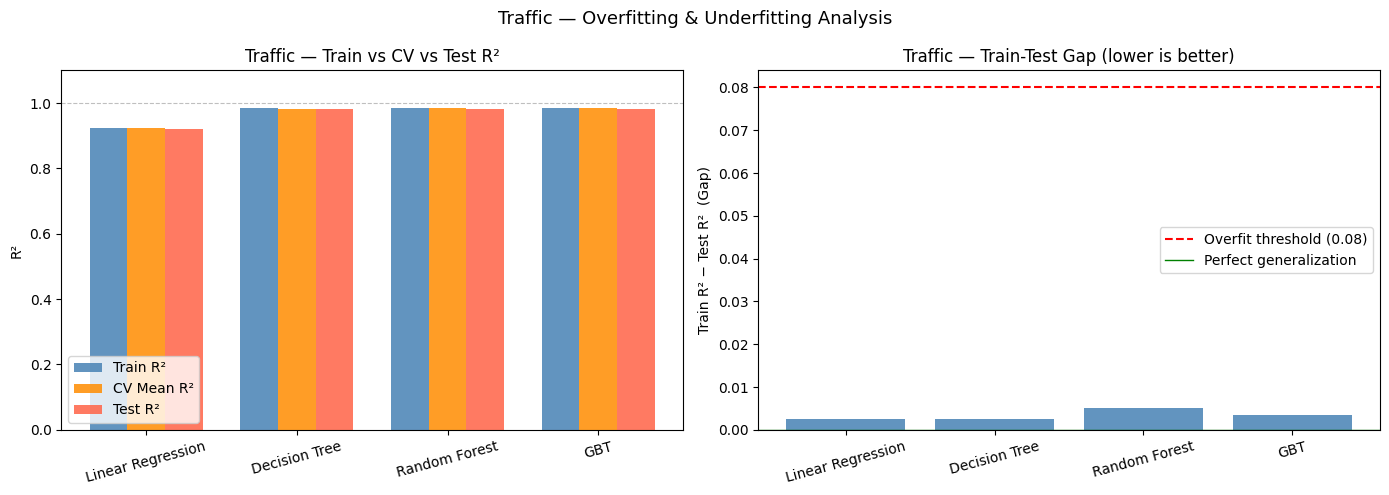

In [29]:
# Overfitting/Underfitting Visual

plot_cv_bars(cv_results_t, "Traffic", "steelblue")

In [30]:
# Select Best Model

best_name_t = best_name_t
best_model_t = results_t[best_name_t]['model']
best_preds_t = results_t[best_name_t]['pred']

print(f"\n✅ Best model for Traffic: {best_name_t}")
print(f" MSE_t : {results_t[best_name_t]['MSE']:.4f}")
print(f" MAE_t : {results_t[best_name_t]['MAE']:.4f}")
print(f" RMSE_t : {results_t[best_name_t]['RMSE']:.4f}")
print(f" R² score_t : {results_t[best_name_t]['R2 score']:.4f}")


✅ Best model for Traffic: Decision Tree
 MSE_t : 10513.8222
 MAE_t : 60.0426
 RMSE_t : 102.5369
 R² score_t : 0.9819


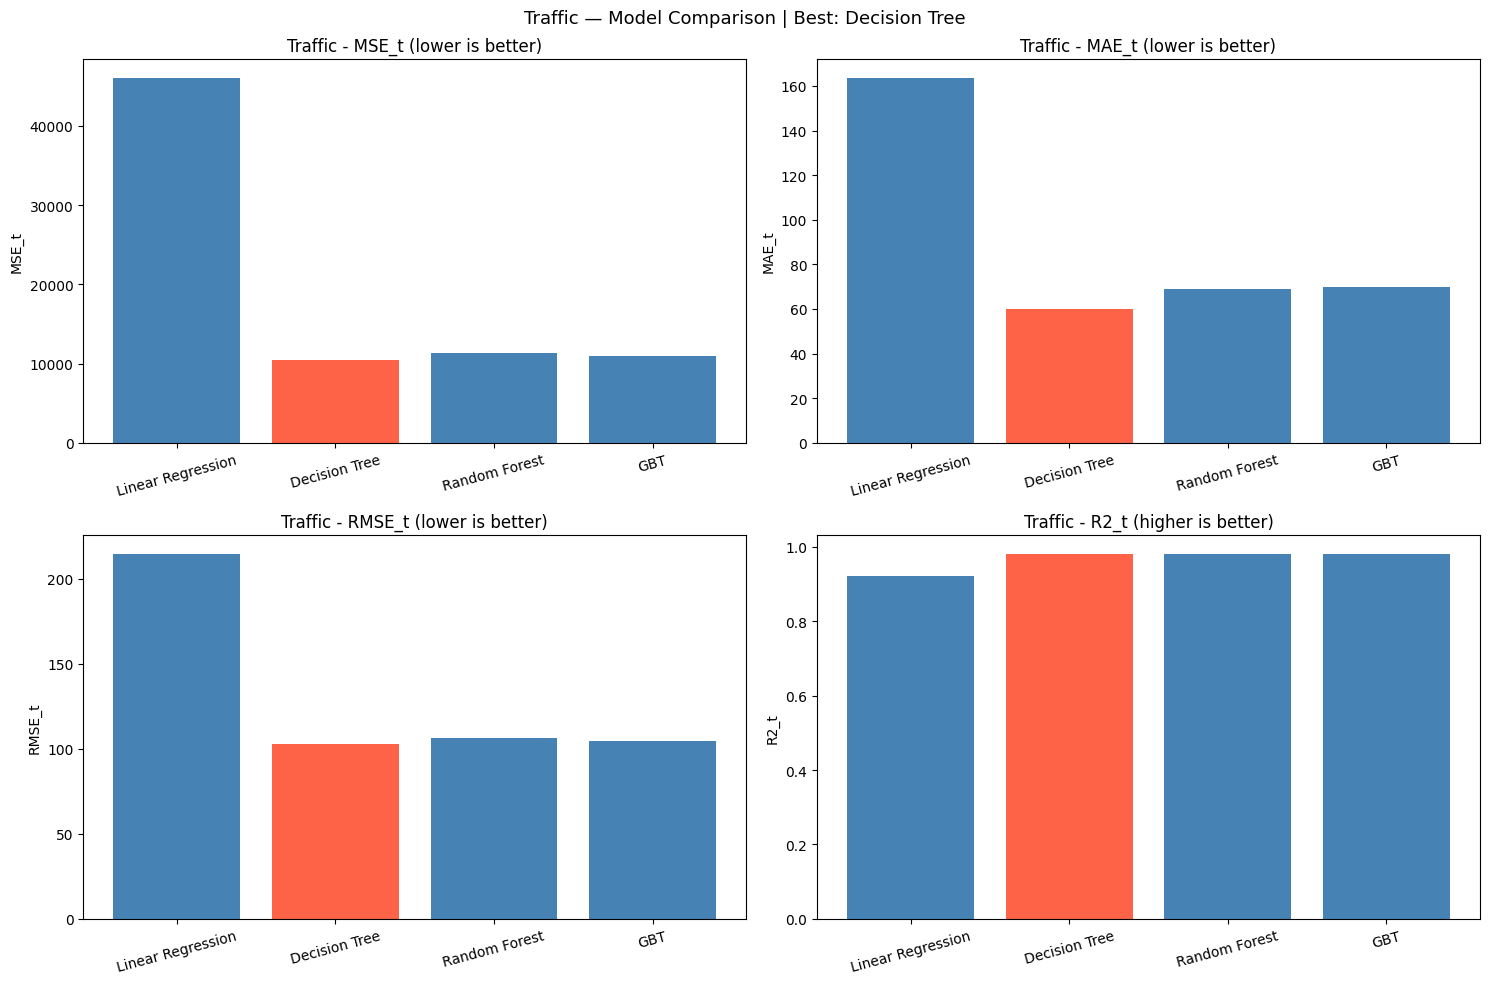

In [31]:
# Comparison Bar Chart

plot_metric_bars(results_t, best_name_t, '_t', "Traffic", "steelblue")

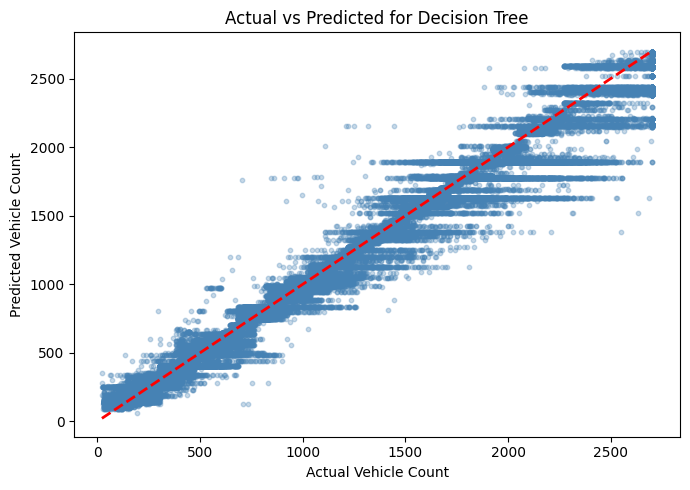

In [32]:
# Actual vs Predicted (Best Model)

plot_actual_vs_pred(results_t, best_name_t, "Actual Vehicle Count", "Predicted Vehicle Count", "steelblue")

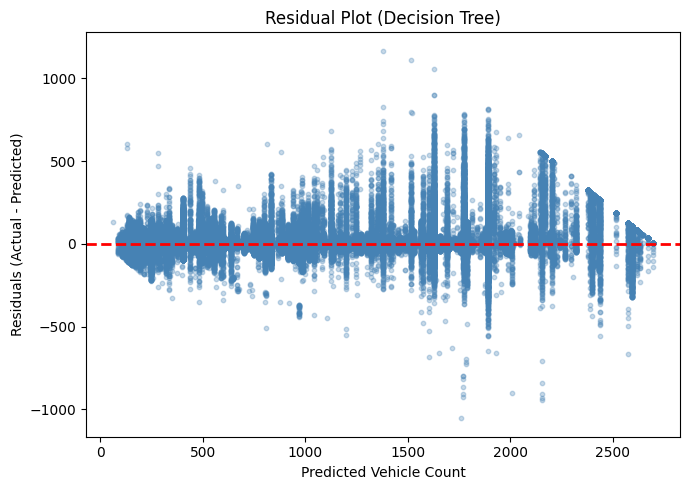

In [33]:
# Residual Plot

plot_residuals(results_t, best_name_t, "Predicted Vehicle Count", "steelblue")

44
44


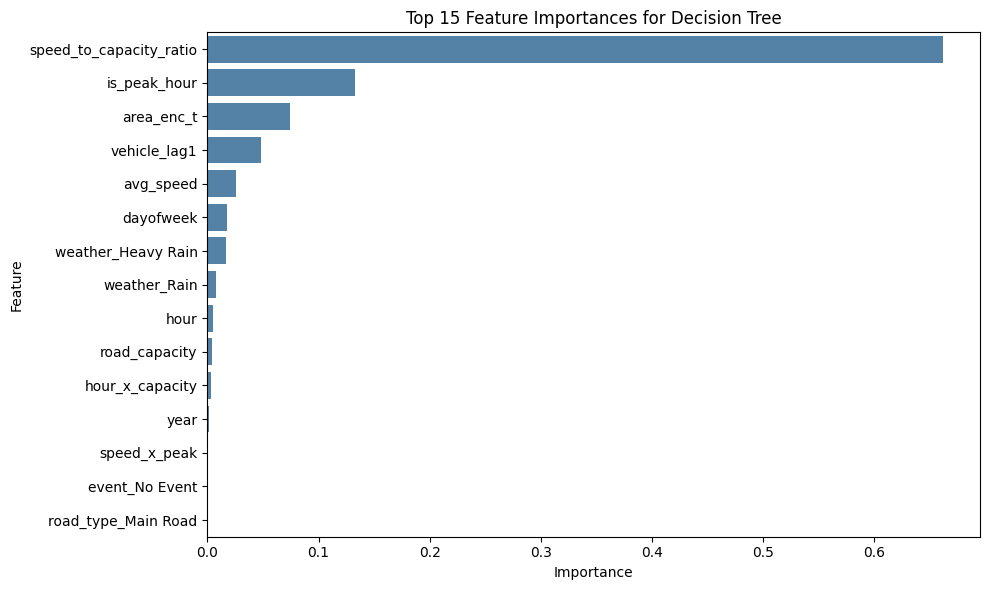

In [34]:
# Feature Importance (Best Model if supported)
expanded_feature_names_t = []

# Numeric features
expanded_feature_names_t.extend(num_cols_t)

# OHE features
for col_name in cat_cols_t:
    labels = enc_model_t.stages[
        cat_cols_t.index(col_name)
    ].labels
    expanded_feature_names_t.extend(
        [f"{col_name}_{lbl}" for lbl in labels]
    )

# Already encoded
expanded_feature_names_t.extend(already_enc_t)
print(len(expanded_feature_names_t))
# Extract the classifier stage from the pipeline
rf_model = best_model_t.stages[-1]   # assuming last stage is your RandomForest/GBT/DecisionTree

# Now safely access feature importances
print(len(rf_model.featureImportances.toArray()))

plot_feature_importance(
    rf_model,                       # pass the classifier, not the pipeline
    expanded_feature_names_t,
    best_name_t,
    "steelblue"
)

**Save the best model**

In [35]:
# Create subfolder for traffic models
traffic_model_dir = f"{MODELS_DIR}/traffic_models"
os.makedirs(traffic_model_dir, exist_ok=True)

# Remove old Spark model folders if they exist
model_paths = [
    f"{traffic_model_dir}/best_model",
    f"{traffic_model_dir}/encoder_model",
    f"{traffic_model_dir}/scaler_model"
]

for path in model_paths:
    if os.path.exists(path):
        shutil.rmtree(path)

# Save Spark models separately
best_model_t.write().overwrite().save(
    f"{traffic_model_dir}/best_model"
)
enc_model_t.write().overwrite().save(
    f"{traffic_model_dir}/encoder_model"
)
sc_model_t.write().overwrite().save(
    f"{traffic_model_dir}/scaler_model"
)

# Convert Spark DataFrame to pandas before saving
area_freq_pd_t = area_freq_t.toPandas()

# Save metadata as pickle
traffic_metadata = {
    'best_name_t': best_name_t,
    'num_cols_t': num_cols_t,
    'cat_cols_t': cat_cols_t,
    'already_encoded_t': already_enc_t,
    'ohe_cols_t': ohe_cols_t,
    'final_feature_cols_t': all_feature_cols_t,
    'area_freq_t': area_freq_pd_t,
    'best_model_path':
        f"{traffic_model_dir}/best_model",
    'encoder_model_path':
        f"{traffic_model_dir}/encoder_model",
    'scaler_model_path':
        f"{traffic_model_dir}/scaler_model",
    'mae_t':          results_t[best_name_t]['MAE'],
    'rmse_t':         results_t[best_name_t]['RMSE'],
    'r2_t':           results_t[best_name_t]['R2 score'],
    'trained_rows_t': train_t.count()
}

joblib.dump(
    traffic_metadata,
    f"{MODELS_DIR}/traffic_metadata.pkl"
)

print(f"✅ Traffic model saved successfully")
print(f"✅ Metadata → {MODELS_DIR}/traffic_metadata.pkl")

# Release cache after save
traffic.unpersist()
train_t.unpersist()
test_t.unpersist()

✅ Traffic model saved successfully
✅ Metadata → saved_models/traffic_metadata.pkl


DataFrame[zone: string, vehicle_count: double, avg_speed: double, road_type: string, weather: string, incident: string, severity: string, event: string, is_weekend: double, is_it_hub: double, season: string, hour: double, day: double, dayofweek: double, month: double, year: double, is_peak_hour: int, road_capacity: double, speed_to_capacity_ratio: double, speed_x_peak: double, hour_x_capacity: double, vehicle_lag1: double, vehicle_lag2: double, area_enc_t: double, zone_idx: double, road_type_idx: double, weather_idx: double, incident_idx: double, severity_idx: double, event_idx: double, season_idx: double, zone_ohe: vector, road_type_ohe: vector, weather_ohe: vector, incident_ohe: vector, severity_ohe: vector, event_ohe: vector, season_ohe: vector, num_raw_t: vector, num_scaled_t: vector, features: vector]

# ============================================ 
# ⚡ ENERGY DATASET
# ============================================

**Load Dataset**

In [36]:
energy = spark.read.parquet(
    f"{CLEAN_DIR}/energy_clean.parquet")
print(f"Energy rows: {energy.count():,} cols: {len(energy.columns)}")
energy.printSchema()

Energy rows: 500,000 cols: 19
root
 |-- timestamp: timestamp (nullable = true)
 |-- area: string (nullable = true)
 |-- zone: string (nullable = true)
 |-- weather: string (nullable = true)
 |-- energy_consumption: double (nullable = true)
 |-- temperature: double (nullable = true)
 |-- humidity: double (nullable = true)
 |-- demand_level: string (nullable = true)
 |-- renewable_usage: double (nullable = true)
 |-- load_type: string (nullable = true)
 |-- is_weekend: double (nullable = true)
 |-- power_outage: double (nullable = true)
 |-- is_it_hub: double (nullable = true)
 |-- season: string (nullable = true)
 |-- hour: double (nullable = true)
 |-- day: double (nullable = true)
 |-- dayofweek: double (nullable = true)
 |-- month: double (nullable = true)
 |-- year: double (nullable = true)



In [37]:
# Define target variable

target_e= 'energy_consumption'

**Feature Engineering**

In [38]:
# PEAK HOUR FEATURE

energy = energy.withColumn(
    "is_peak_hour",
    F.when(
        ((F.col("hour") >= 6) & (F.col("hour") <= 9)) |
        ((F.col("hour") >= 11) & (F.col("hour") <=15)) |
        ((F.col("hour") >= 18) & (F.col("hour") <=22)),
        1
    ).otherwise(0)
)

In [39]:
# TEMPERATURE-HUMIDITY DISCOMFORT INDEX

energy = energy.withColumn(
    "temp_humidity_discomfort",
    F.col("temperature") - (
        F.lit(0.55) * (F.lit(1.0) - F.col("humidity") / F.lit(100.0)) *
        (F.col("temperature") - F.lit(14.5))
    )
)

In [40]:
# TEMPERATURE THRESHOLD FLAGS

energy = energy.withColumn("high_temp_flag", (F.col("temperature") > 30).cast("int")) \
    .withColumn("very_high_temp", (F.col("temperature") > 34).cast("int")) \
    .withColumn("is_extreme_cold", (F.col("temperature") < 18).cast("int")) \
    .withColumn("temp_squared", F.col("temperature") * F.col("temperature"))

In [41]:
# LAG FEATURES

w_area_ts_e = Window.partitionBy("area").orderBy("timestamp")
w_ffill_e = Window.partitionBy("area").orderBy("timestamp").rowsBetween(Window.unboundedPreceding, 0)

energy = energy.withColumn("lag_energy1", F.lag("energy_consumption", 1).over(w_area_ts_e)) \
    .withColumn("lag_energy2", F.lag("energy_consumption", 2).over(w_area_ts_e))

energy = energy.withColumn("lag_energy1", F.coalesce(F.last("lag_energy1", True).over(w_ffill_e), F.lit(0.0))) \
    .withColumn("lag_energy2", F.coalesce(F.last("lag_energy2", True).over(w_ffill_e), F.lit(0.0)))

In [42]:
# INTERACTION FEATURES

energy = energy.withColumn("temp_humidity_interaction", F.col("temperature") * F.col("humidity")) \
    .withColumn("peak_temp_interaction", F.col("is_peak_hour") * F.col("temperature"))

In [43]:
# Drop timestamp column

energy = energy.drop('demand_level')

energy = energy.cache()
energy.count()

500000

**Split Data**

In [44]:
energy_sorted = energy.orderBy("timestamp")
total_rows_e = energy_sorted.count()
train_rows_e = int(total_rows_e * 0.8)

# Window for row numbering
w = Window.orderBy("timestamp")

# Add row numbers
energy_sorted = energy_sorted.withColumn(
    "row_num",
    F.row_number().over(w)
)

# Train-Test split
train_e = energy_sorted.filter(
    F.col("row_num") <= train_rows_e
)

test_e = energy_sorted.filter(
    F.col("row_num") > train_rows_e
)

# Drop unnecessary columns
train_e = train_e.drop("row_num", "timestamp")
test_e = test_e.drop("row_num", "timestamp")

print(f"Train rows: {train_e.count():,}")
print(f"Test rows : {test_e.count():,}")

Train rows: 400,000
Test rows : 100,000


**Encoding**

In [45]:
# Frequency Encoding for 'area' feature

area_freq_e = (
    train_e.groupBy("area")
    .agg((F.count("*") / train_e.count()).alias("area_enc_e"))
)

train_e = train_e.join(area_freq_e, on="area", how="left")
test_e = test_e.join(area_freq_e, on="area", how="left")

# Handle unseen areas in test (rare but safe)
test_e = test_e.fillna({"area_enc_e": 0.0})

# Drop original area column
train_e = train_e.drop("area")
test_e = test_e.drop("area")

In [46]:
# Define numerical and categorical columns

cat_cols_e= ['zone', 'weather', 'load_type', 'season']
already_enc_e= ['area_enc_e', 'is_it_hub', 'is_weekend', 'power_outage']
num_cols_e= [c for c in train_e.columns
             if c not in cat_cols_e + already_enc_e + [target_e]]

print("Categorical cols: ", cat_cols_e)
print("Already-encoded: ", already_enc_e)
print("Numeric cols:", num_cols_e)

Categorical cols:  ['zone', 'weather', 'load_type', 'season']
Already-encoded:  ['area_enc_e', 'is_it_hub', 'is_weekend', 'power_outage']
Numeric cols: ['temperature', 'humidity', 'renewable_usage', 'hour', 'day', 'dayofweek', 'month', 'year', 'is_peak_hour', 'temp_humidity_discomfort', 'high_temp_flag', 'very_high_temp', 'is_extreme_cold', 'temp_squared', 'lag_energy1', 'lag_energy2', 'temp_humidity_interaction', 'peak_temp_interaction']


In [47]:
# StringIndexer + OneHotEncoder for categorical features
indexers_e = [StringIndexer(inputCol=c, outputCol=f"{c}_idx",
                          handleInvalid='keep') for c in cat_cols_e]
encoder_e = OneHotEncoder(inputCols=[f"{c}_idx" for c in cat_cols_e],
                        outputCols=[f"{c}_ohe" for c in cat_cols_e])

In [48]:
# Fit pipeline on train, transform both train and test

enc_pipeline_e = Pipeline(stages=indexers_e + [encoder_e])
enc_model_e = enc_pipeline_e.fit(train_e)
train_e = enc_model_e.transform(train_e)
test_e = enc_model_e.transform(test_e)

for idx in indexers_e:
    print(idx.getOutputCol(), enc_model_e.stages[cat_cols_e.index(idx.getInputCol())].labels)

ohe_cols_e = [f"{c}_ohe" for c in cat_cols_e]
train_e.select(ohe_cols_e[:]).show()

zone_idx ['South', 'East', 'West', 'North', 'Central']
weather_idx ['Clear', 'Cloudy', 'Rain', 'Heavy Rain']
load_type_idx ['Residential', 'Commercial', 'Industrial']
season_idx ['Winter', 'Monsoon', 'Summer']
+-------------+-------------+-------------+-------------+
|     zone_ohe|  weather_ohe|load_type_ohe|   season_ohe|
+-------------+-------------+-------------+-------------+
|(5,[3],[1.0])|(4,[0],[1.0])|(3,[0],[1.0])|(3,[0],[1.0])|
|(5,[0],[1.0])|(4,[0],[1.0])|(3,[1],[1.0])|(3,[0],[1.0])|
|(5,[0],[1.0])|(4,[0],[1.0])|(3,[1],[1.0])|(3,[0],[1.0])|
|(5,[0],[1.0])|(4,[0],[1.0])|(3,[1],[1.0])|(3,[0],[1.0])|
|(5,[0],[1.0])|(4,[1],[1.0])|(3,[1],[1.0])|(3,[0],[1.0])|
|(5,[0],[1.0])|(4,[1],[1.0])|(3,[1],[1.0])|(3,[0],[1.0])|
|(5,[0],[1.0])|(4,[1],[1.0])|(3,[1],[1.0])|(3,[0],[1.0])|
|(5,[0],[1.0])|(4,[1],[1.0])|(3,[1],[1.0])|(3,[0],[1.0])|
|(5,[0],[1.0])|(4,[1],[1.0])|(3,[1],[1.0])|(3,[0],[1.0])|
|(5,[0],[1.0])|(4,[1],[1.0])|(3,[1],[1.0])|(3,[0],[1.0])|
|(5,[0],[1.0])|(4,[1],[1.0])|(3,[1],

**Standardize Features**

In [49]:
num_assembler_e = VectorAssembler(inputCols=num_cols_e, outputCol="num_raw_e", handleInvalid="skip")
scaler_e= SparkScaler(inputCol="num_raw_e", outputCol="num_scaled_e", withMean=False, withStd=True)

sc_pipeline_e = Pipeline(stages=[num_assembler_e, scaler_e])
sc_model_e = sc_pipeline_e.fit(train_e)
train_e = sc_model_e.transform(train_e)
test_e = sc_model_e.transform(test_e) 

print("Standardization complete")
train_e.select("num_scaled_e").show(truncate=False)

Standardization complete
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|num_scaled_e                                                                                                                                                                                                                                                                                              |
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|(18,[0,1,2,4,5,6,7,9,13,16],[4.181498626729757,3.9463324467714616,0.108

In [50]:
# Final feature assembly - combine scaled numeric + OHE + already encoded
all_feature_cols_e = ["num_scaled_e"] + ohe_cols_e + already_enc_e

# VectorAssembler merges all feature vectors into one 'features' vector
final_assembler_e = VectorAssembler(inputCols=all_feature_cols_e, outputCol="features", handleInvalid="skip")
train_e = final_assembler_e.transform(train_e)
test_e = final_assembler_e.transform(test_e)

train_e = train_e.cache()
test_e = test_e.cache()
train_e.count()
test_e.count()

print("Feature assembly complete")
train_e.select("features", target_e).show()

Feature assembly complete
+--------------------+------------------+
|            features|energy_consumption|
+--------------------+------------------+
|(37,[0,1,2,3,4,5,...|            5200.7|
|(37,[0,1,2,3,4,5,...|            5883.0|
|(37,[0,1,2,3,4,5,...|            6307.7|
|(37,[0,1,2,3,4,5,...|            6742.0|
|(37,[0,1,2,3,4,5,...|            6545.5|
|(37,[0,1,2,3,4,5,...|            6356.9|
|(37,[0,1,2,3,4,5,...|            6440.1|
|(37,[0,1,2,3,4,5,...|            5357.5|
|(37,[0,1,2,3,4,5,...|            4491.9|
|(37,[0,1,3,4,5,6,...|            4015.5|
|(37,[0,1,3,4,5,6,...|            3869.2|
|(37,[0,1,3,4,5,6,...|            3752.3|
|(37,[0,1,2,3,4,6,...|            4674.5|
|(37,[0,1,2,3,4,6,...|            5205.6|
|(37,[0,1,2,3,4,5,...|            4513.4|
|(37,[0,1,2,3,4,5,...|            4453.1|
|(37,[0,1,2,3,4,5,...|            4757.8|
|(37,[0,1,2,3,4,5,...|            5446.7|
|(37,[0,1,2,3,4,5,...|            6301.5|
|(37,[0,1,2,3,4,5,...|            6752.7|
+-------

**Train Models**

In [51]:
# Define Models

models_def_e = {
    'Linear Regression' : SparkLR(
        labelCol=target_e, featuresCol="features", maxIter=100
    ),

    'Decision Tree': SparkDT(
        labelCol=target_e, featuresCol="features", seed=42, maxDepth=10
    ),

    'Random Forest': SparkRF(
        labelCol=target_e, featuresCol="features", seed=42, numTrees=50, maxDepth=10
    ),

    'GBT': SparkGBT(
        labelCol=target_e, featuresCol="features", seed=42, maxDepth=5, maxIter=50, stepSize=0.1, subsamplingRate=0.8
    )
}

In [52]:
# Train & Evaluate All Models

results_e, best_name_e = train_and_evaluate(
    train_e, test_e, ["features"], target_e, models_def_e, "Energy", "seagreen"
)



 Energy - Model Training and Evaluation
Model                              RMSE        MAE            MSE       R²           Time
-----------------------------------------------------------------------------------------------
 Linear Regression              489.0598   306.3474    239179.4783   0.9589 (17.4s)
 Decision Tree                  474.4008   286.8125    225056.1582   0.9613 (20.1s)
 Random Forest                  455.3031   279.8857    207300.9015   0.9644 (237.3s)
 GBT                            407.2814   236.8137    165878.1166   0.9715 (164.6s)


In [53]:
# Overfitting & Underfitting Check

cv_results_e = cv_overfit_check(train_e, ["features"], target_e, results_e, "Energy")



  Energy - OVERFITTING and UNDERFITTING CHECK (Pyspark 3-fold CV)
Model                          Train R²   CV Mean R²    Test R²        Gap          Status
-----------------------------------------------------------------------------------------------
Linear Regression                0.9613       0.9613     0.9589     0.0025      🟢 Good Fit
Decision Tree                    0.9701       0.9654     0.9613     0.0088      🟢 Good Fit
Random Forest                    0.9731       0.9714     0.9644     0.0087      🟢 Good Fit
GBT                              0.9755       0.9746     0.9715     0.0040      🟢 Good Fit
\nStatus Guide:
  🟢 Good Fit    → Train R² ≈ CV R² ≈ Test R²  — model generalizes well
  🔴 Overfitting → Train R² >> Test R²          — model memorized training data
  🟡 Underfitting→ Train R² and Test R² both low — model too simple
  🟠 Unstable    → Large Train–Test Gap          — model sensitive to data splits


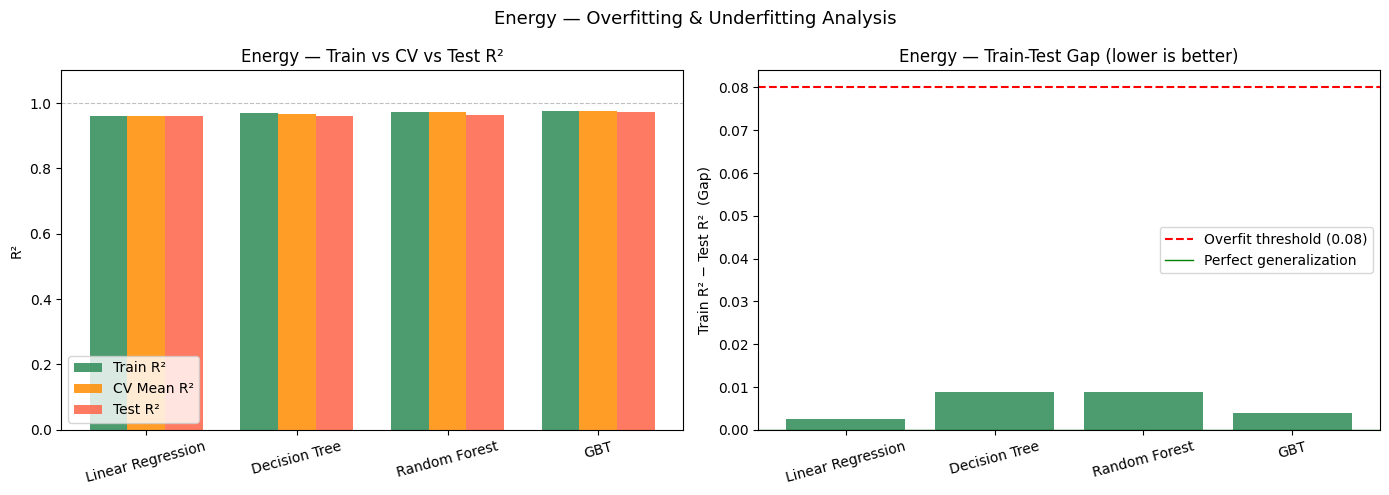

In [54]:
# Overfitting/Underfitting Visual

plot_cv_bars(cv_results_e, "Energy", "seagreen")

In [55]:
# Select Best Model

best_name_e = best_name_e
best_model_e = results_e[best_name_e]['model']
best_preds_e = results_e[best_name_e]['pred']

print(f"\n✅ Best model for Energy: {best_name_e}")
print(f" MSE_e : {results_e[best_name_e]['MSE']:.4f}")
print(f" MAE_e : {results_e[best_name_e]['MAE']:.4f}")
print(f" RMSE_e : {results_e[best_name_e]['RMSE']:.4f}")
print(f" R² score_e : {results_e[best_name_e]['R2 score']:.4f}")


✅ Best model for Energy: GBT
 MSE_e : 165878.1166
 MAE_e : 236.8137
 RMSE_e : 407.2814
 R² score_e : 0.9715


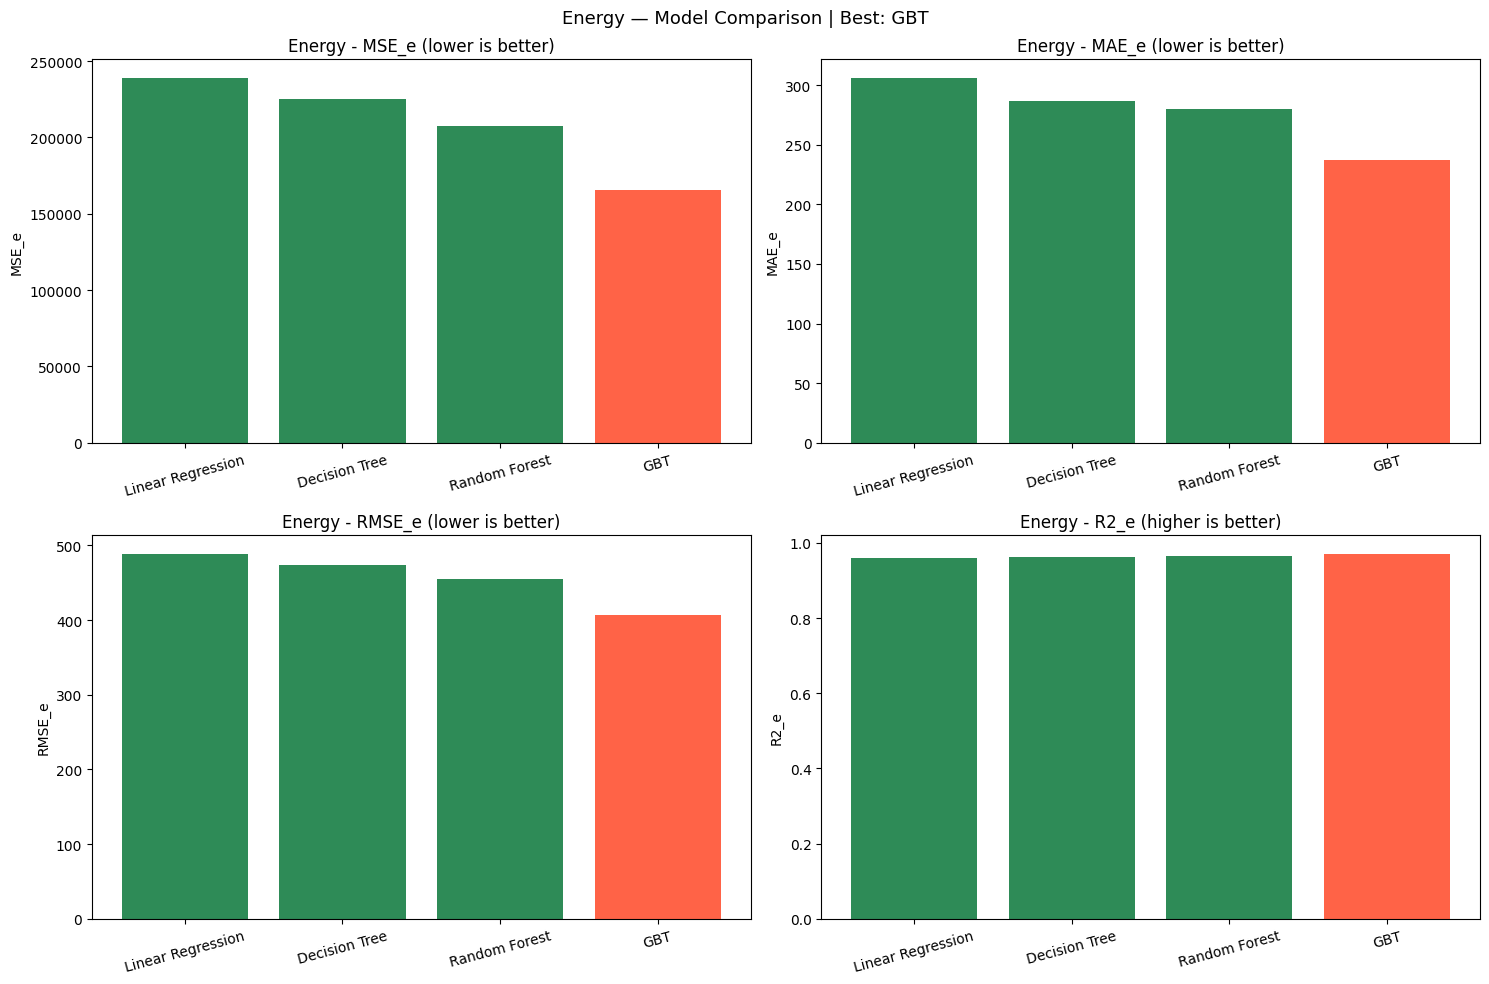

In [56]:
# Comparison Bar Chart

plot_metric_bars(results_e, best_name_e, '_e', "Energy", "seagreen")

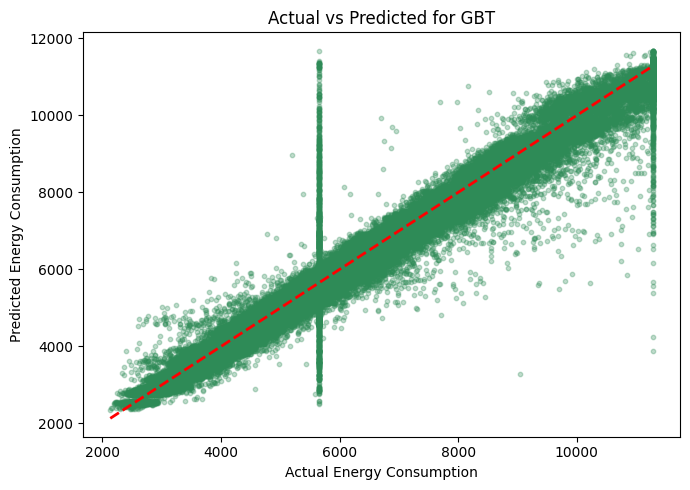

In [57]:
# Actual vs Predicted (Best Model)

plot_actual_vs_pred(results_e, best_name_e, "Actual Energy Consumption", "Predicted Energy Consumption", "seagreen")

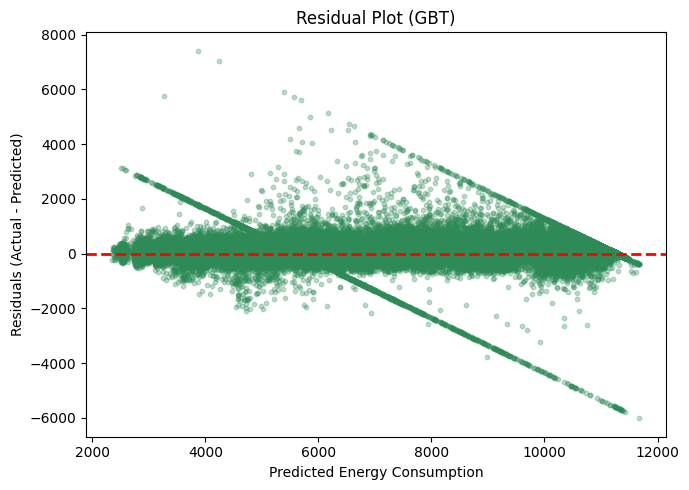

In [58]:
# Residual Plot

plot_residuals(results_e, best_name_e, "Predicted Energy Consumption", "seagreen")

37
37
37


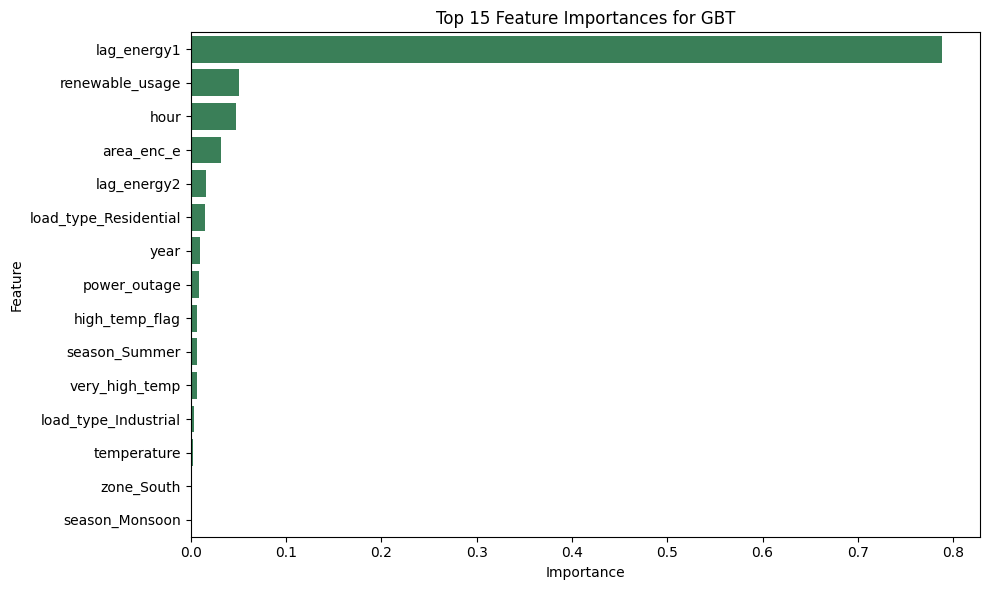

In [59]:
# Feature Importance (Best Model if supported)

expanded_feature_names_e = []

# Numeric features
expanded_feature_names_e.extend(num_cols_e)

# OHE features
for col_name in cat_cols_e:
    labels = enc_model_e.stages[
        cat_cols_e.index(col_name)
    ].labels
    expanded_feature_names_e.extend(
        [f"{col_name}_{lbl}" for lbl in labels]
    )

# Already encoded
expanded_feature_names_e.extend(already_enc_e)
print(len(expanded_feature_names_e))
print(len(expanded_feature_names_e))
# Extract the classifier stage from the pipeline
rf_model = best_model_e.stages[-1]   # assuming last stage is your RandomForest/GBT/DecisionTree

# Now safely access feature importances
print(len(rf_model.featureImportances.toArray()))

plot_feature_importance(
    rf_model,                       # pass the classifier, not the pipeline
    expanded_feature_names_e,
    best_name_e,
    "seagreen"
)


**Save the best model**

In [60]:
# Create subfolder for energy models
energy_model_dir = f"{MODELS_DIR}/energy_models"
os.makedirs(energy_model_dir, exist_ok=True)

# Remove old Spark model folders if they exist
model_paths = [
    f"{energy_model_dir}/best_model",
    f"{energy_model_dir}/encoder_model",
    f"{energy_model_dir}/scaler_model"
]

for path in model_paths:
    if os.path.exists(path):
        shutil.rmtree(path)

# Save Spark models separately
best_model_e.write().overwrite().save(
    f"{energy_model_dir}/best_model"
)
enc_model_e.write().overwrite().save(
    f"{energy_model_dir}/encoder_model"
)
sc_model_e.write().overwrite().save(
    f"{energy_model_dir}/scaler_model"
)

# Convert Spark DataFrame to pandas before saving
area_freq_pd_e = area_freq_e.toPandas()

# Save metadata as pickle
energy_metadata = {
    'best_name_e': best_name_e,
    'num_cols_e': num_cols_e,
    'cat_cols_e': cat_cols_e,
    'already_encoded_e': already_enc_e,
    'ohe_cols_e': ohe_cols_e,
    'final_feature_cols_e': all_feature_cols_e,
    'area_freq_e': area_freq_pd_e,
    'best_model_path':
        f"{energy_model_dir}/best_model",
    'encoder_model_path':
        f"{energy_model_dir}/encoder_model",
    'scaler_model_path':
        f"{energy_model_dir}/scaler_model",
    'mae_e':          results_e[best_name_e]['MAE'],
    'rmse_e':         results_e[best_name_e]['RMSE'],
    'r2_e':           results_e[best_name_e]['R2 score'],
    'trained_rows_e': train_e.count()
}

joblib.dump(
    energy_metadata,
    f"{MODELS_DIR}/energy_metadata.pkl"
)

print(f"✅ Energy model saved successfully")
print(f"✅ Metadata → {MODELS_DIR}/energy_metadata.pkl")

# Release cache after save
energy.unpersist()
train_e.unpersist()
test_e.unpersist()

✅ Energy model saved successfully
✅ Metadata → saved_models/energy_metadata.pkl


DataFrame[zone: string, weather: string, energy_consumption: double, temperature: double, humidity: double, renewable_usage: double, load_type: string, is_weekend: double, power_outage: double, is_it_hub: double, season: string, hour: double, day: double, dayofweek: double, month: double, year: double, is_peak_hour: int, temp_humidity_discomfort: double, high_temp_flag: int, very_high_temp: int, is_extreme_cold: int, temp_squared: double, lag_energy1: double, lag_energy2: double, temp_humidity_interaction: double, peak_temp_interaction: double, area_enc_e: double, zone_idx: double, weather_idx: double, load_type_idx: double, season_idx: double, zone_ohe: vector, weather_ohe: vector, load_type_ohe: vector, season_ohe: vector, num_raw_e: vector, num_scaled_e: vector, features: vector]

# ============================================
# 🌫️ POLLUTION DATASET
# ============================================

**Load Dataset**

In [61]:
pollution = spark.read.parquet(
    f"{CLEAN_DIR}/pollution_clean.parquet")
print(f"Pollution rows: {pollution.count():,} cols: {len(pollution.columns)}")
pollution.printSchema()

Pollution rows: 500,000 cols: 19
root
 |-- timestamp: timestamp (nullable = true)
 |-- area: string (nullable = true)
 |-- zone: string (nullable = true)
 |-- AQI: double (nullable = true)
 |-- PM2_5: double (nullable = true)
 |-- PM10: double (nullable = true)
 |-- NO2: double (nullable = true)
 |-- CO: double (nullable = true)
 |-- weather: string (nullable = true)
 |-- temperature: double (nullable = true)
 |-- humidity: double (nullable = true)
 |-- is_weekend: double (nullable = true)
 |-- is_it_hub: double (nullable = true)
 |-- season: string (nullable = true)
 |-- hour: double (nullable = true)
 |-- day: double (nullable = true)
 |-- dayofweek: double (nullable = true)
 |-- month: double (nullable = true)
 |-- year: double (nullable = true)



In [62]:
# Define target variable

target_p= 'AQI'

**Feature Engineering**

In [63]:
# Temperature - Humidity Interaction

pollution = pollution.withColumn("temp_humidity_interaction", F.col("temperature") * F.col("humidity"))

In [64]:
# Pollution Inversion Risk

pollution = pollution.withColumn("temp_inversion_risk", F.col("temperature") / (F.col("humidity") + F.lit(1.0)))

In [65]:
# Peak Hour Indicator

pollution = pollution.withColumn(
    "peak_hour",
    F.when(
        ((F.col("hour") >= 7) & (F.col("hour") <= 10)) |
        ((F.col("hour") >= 11) & (F.col("hour") <= 16)) |
        ((F.col("hour") >= 17) & (F.col("hour") <= 21)),
        1
    ).otherwise(0)
)

In [66]:
# LOW HUMIDITY FLAG

pollution = pollution.withColumn("low_humidity_flag", (F.col("humidity") < 45).cast("int"))

In [67]:
# LAG feature for AQI

w_area_ts_p = Window.partitionBy("area").orderBy("timestamp")
w_ffill_p = Window.partitionBy("area").orderBy("timestamp").rowsBetween(Window.unboundedPreceding, 0)

pollution = pollution.withColumn("aqi_lag1", F.lag("AQI", 1).over(w_area_ts_p)) \
    .withColumn("aqi_lag2", F.lag("AQI", 2).over(w_area_ts_p)) 

pollution = pollution.withColumn("aqi_lag1", F.coalesce(F.last("aqi_lag1", True).over(w_ffill_p), F.lit(0.0))) \
    .withColumn("aqi_lag2", F.coalesce(F.last("aqi_lag2", True).over(w_ffill_p), F.lit(0.0)))

In [68]:
# Drop unnecessary columns

pollution = pollution.drop('PM2_5', 'PM10', 'NO2', 'CO')

pollution = pollution.cache()
pollution.count()

500000

**Split Data**

In [69]:
pollution_sorted = pollution.orderBy("timestamp")
total_rows_p = pollution_sorted.count()
train_rows_p = int(total_rows_p * 0.8)

# Window for row numbering
w = Window.orderBy("timestamp")

# Add row numbers
pollution_sorted = pollution_sorted.withColumn(
    "row_num",
    F.row_number().over(w)
)

# Train-Test split
train_p = pollution_sorted.filter(
    F.col("row_num") <= train_rows_p
)

test_p = pollution_sorted.filter(
    F.col("row_num") > train_rows_p
)

# Drop unnecessary columns
train_p = train_p.drop("row_num", "timestamp")
test_p = test_p.drop("row_num", "timestamp")

print(f"Train rows: {train_p.count():,}")
print(f"Test rows : {test_p.count():,}")

Train rows: 400,000
Test rows : 100,000


**Encoding**

In [70]:
# Frequency Encoding for 'area' feature

area_freq_p = (
    train_p.groupBy("area")
    .agg((F.count("*") / train_p.count()).alias("area_enc_p"))
)

train_p = train_p.join(area_freq_p, on="area", how="left")
test_p = test_p.join(area_freq_p, on="area", how="left")

# Handle unseen areas in test (rare but safe)
test_p = test_p.fillna({"area_enc_p": 0.0})

# Drop original area column
train_p = train_p.drop("area")
test_p = test_p.drop("area")

In [71]:
# Define numerical and categorical columns

cat_cols_p= ['zone', 'weather', 'season']
already_enc_p= ['area_enc_p', 'is_it_hub', 'is_weekend']
num_cols_p= [c for c in train_p.columns
             if c not in cat_cols_p + already_enc_p + [target_p]]

print("Categorical cols: ", cat_cols_p)
print("Already-encoded: ", already_enc_p)
print("Numeric cols:", num_cols_p)

Categorical cols:  ['zone', 'weather', 'season']
Already-encoded:  ['area_enc_p', 'is_it_hub', 'is_weekend']
Numeric cols: ['temperature', 'humidity', 'hour', 'day', 'dayofweek', 'month', 'year', 'temp_humidity_interaction', 'temp_inversion_risk', 'peak_hour', 'low_humidity_flag', 'aqi_lag1', 'aqi_lag2']


In [72]:
# StringIndexer + OneHotEncoder for categorical features
indexers_p = [StringIndexer(inputCol=c, outputCol=f"{c}_idx",
                          handleInvalid='keep') for c in cat_cols_p]
encoder_p = OneHotEncoder(inputCols=[f"{c}_idx" for c in cat_cols_p],
                        outputCols=[f"{c}_ohe" for c in cat_cols_p])

In [73]:
# Fit pipeline on train, transform both train and test

enc_pipeline_p = Pipeline(stages=indexers_p + [encoder_p])
enc_model_p = enc_pipeline_p.fit(train_p)
train_p = enc_model_p.transform(train_p)
test_p = enc_model_p.transform(test_p)

for idx in indexers_p:
    print(idx.getOutputCol(), enc_model_p.stages[cat_cols_p.index(idx.getInputCol())].labels)

ohe_cols_p = [f"{c}_ohe" for c in cat_cols_p]
train_p.select(ohe_cols_p[:]).show()

zone_idx ['South', 'East', 'West', 'North', 'Central']
weather_idx ['Clear', 'Cloudy', 'Rain', 'Heavy Rain']
season_idx ['Winter', 'Monsoon', 'Summer']
+-------------+-------------+-------------+
|     zone_ohe|  weather_ohe|   season_ohe|
+-------------+-------------+-------------+
|(5,[3],[1.0])|(4,[0],[1.0])|(3,[0],[1.0])|
|(5,[0],[1.0])|(4,[0],[1.0])|(3,[0],[1.0])|
|(5,[0],[1.0])|(4,[0],[1.0])|(3,[0],[1.0])|
|(5,[0],[1.0])|(4,[0],[1.0])|(3,[0],[1.0])|
|(5,[0],[1.0])|(4,[1],[1.0])|(3,[0],[1.0])|
|(5,[0],[1.0])|(4,[1],[1.0])|(3,[0],[1.0])|
|(5,[0],[1.0])|(4,[1],[1.0])|(3,[0],[1.0])|
|(5,[0],[1.0])|(4,[1],[1.0])|(3,[0],[1.0])|
|(5,[0],[1.0])|(4,[1],[1.0])|(3,[0],[1.0])|
|(5,[0],[1.0])|(4,[1],[1.0])|(3,[0],[1.0])|
|(5,[0],[1.0])|(4,[1],[1.0])|(3,[0],[1.0])|
|(5,[0],[1.0])|(4,[1],[1.0])|(3,[0],[1.0])|
|(5,[0],[1.0])|(4,[1],[1.0])|(3,[0],[1.0])|
|(5,[3],[1.0])|(4,[0],[1.0])|(3,[0],[1.0])|
|(5,[3],[1.0])|(4,[0],[1.0])|(3,[0],[1.0])|
|(5,[3],[1.0])|(4,[0],[1.0])|(3,[0],[1.0])|
|(5,[3],[1.0

**Standardize Features**

In [74]:
num_assembler_p = VectorAssembler(inputCols=num_cols_p, outputCol="num_raw_p", handleInvalid="skip")
scaler_p= SparkScaler(inputCol="num_raw_p", outputCol="num_scaled_p", withMean=False, withStd=True)

sc_pipeline_p = Pipeline(stages=[num_assembler_p, scaler_p])
sc_model_p = sc_pipeline_p.fit(train_p)
train_p = sc_model_p.transform(train_p)
test_p = sc_model_p.transform(test_p) 

print("Standardization complete")
train_p.select("num_scaled_p").show(truncate=False)

Standardization complete
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|num_scaled_p                                                                                                                                                                                                                          |
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|[4.18149862672976,3.9463324467714593,0.0,0.11385901595085428,1.9988536060497188,0.29211522772517917,544.0616421433435,2.5465676137714177,2.6802757968276927,0.0,0.0,0.0,0.0]                                                          |
|[3.804965575033715,3.657576414080865,0.0,0

In [75]:
# Final feature assembly - combine scaled numeric + OHE + already encoded
all_feature_cols_p = ["num_scaled_p"] + ohe_cols_p + already_enc_p

# VectorAssembler merges all feature vectors into one 'features' vector
final_assembler_p = VectorAssembler(inputCols=all_feature_cols_p, outputCol="features", handleInvalid="skip")
train_p = final_assembler_p.transform(train_p)
test_p = final_assembler_p.transform(test_p)

train_p = train_p.cache()
test_p = test_p.cache()
train_p.count()
test_p.count()

print("Feature assembly complete")
train_p.select("features", target_p).show()

Feature assembly complete
+--------------------+-----+
|            features|  AQI|
+--------------------+-----+
|(28,[0,1,2,3,4,5,...|128.0|
|(28,[0,1,2,3,4,5,...|154.0|
|(28,[0,1,2,3,4,5,...|168.0|
|[5.07328743337828...|176.0|
|(28,[0,1,2,3,4,5,...|184.0|
|(28,[0,1,2,3,4,5,...|195.0|
|(28,[0,1,2,3,4,5,...|207.0|
|(28,[0,1,2,3,4,5,...|191.0|
|(28,[0,1,2,3,4,5,...|181.0|
|(28,[0,1,2,3,4,5,...|171.0|
|(28,[0,1,2,3,4,5,...|172.0|
|(28,[0,1,2,3,4,5,...|166.0|
|(28,[0,1,2,3,5,6,...|214.0|
|(28,[0,1,2,3,5,6,...|232.0|
|(28,[0,1,2,3,4,5,...|219.0|
|[4.30040380094956...|203.0|
|(28,[0,1,2,3,4,5,...|192.0|
|[4.89492967204858...|184.0|
|(28,[0,1,2,3,4,5,...|181.0|
|(28,[0,1,2,3,4,5,...|188.0|
+--------------------+-----+
only showing top 20 rows



**Train Models**

In [76]:
# Define Models

models_def_p = {
    'Linear Regression' : SparkLR(
        labelCol=target_p, featuresCol="features", maxIter=100
    ),

    'Decision Tree': SparkDT(
        labelCol=target_p, featuresCol="features", seed=42, maxDepth=10
    ),

    'Random Forest': SparkRF(
        labelCol=target_p, featuresCol="features", seed=42, numTrees=50, maxDepth=10
    ),

    'GBT': SparkGBT(
        labelCol=target_p, featuresCol="features", seed=42, maxDepth=5, maxIter=50, stepSize=0.1, subsamplingRate=0.8
    )
}

In [78]:
# Train & Evaluate All Models

results_p, best_name_p = train_and_evaluate(
    train_p, test_p, ["features"], target_p, models_def_p, "Pollution", "mediumpurple"
)



 Pollution - Model Training and Evaluation
Model                              RMSE        MAE            MSE       R²           Time
-----------------------------------------------------------------------------------------------
 Linear Regression               13.4479     9.6205       180.8449   0.9620 (29.5s)
 Decision Tree                   12.5341     8.2289       157.1027   0.9670 (22.0s)
 Random Forest                   12.5149     8.3479       156.6234   0.9671 (176.3s)
 GBT                              9.8162     6.9763        96.3582   0.9797 (131.9s)


In [79]:
# Overfitting & Underfitting Check

cv_results_p = cv_overfit_check(train_p, ["features"], target_p, results_p, "Pollution")



  Pollution - OVERFITTING and UNDERFITTING CHECK (Pyspark 3-fold CV)
Model                          Train R²   CV Mean R²    Test R²        Gap          Status
-----------------------------------------------------------------------------------------------


Linear Regression                0.9745       0.9745     0.9620     0.0126      🟢 Good Fit
Decision Tree                    0.9790       0.9784     0.9670     0.0120      🟢 Good Fit
Random Forest                    0.9795       0.9789     0.9671     0.0124      🟢 Good Fit
GBT                              0.9867       0.9868     0.9797     0.0069      🟢 Good Fit
\nStatus Guide:
  🟢 Good Fit    → Train R² ≈ CV R² ≈ Test R²  — model generalizes well
  🔴 Overfitting → Train R² >> Test R²          — model memorized training data
  🟡 Underfitting→ Train R² and Test R² both low — model too simple
  🟠 Unstable    → Large Train–Test Gap          — model sensitive to data splits


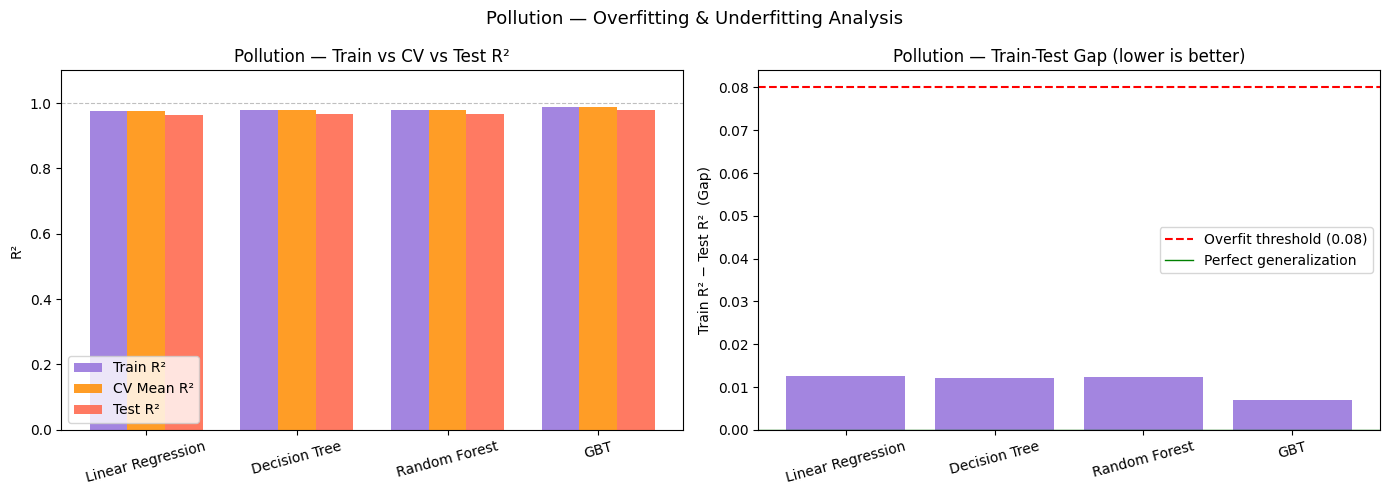

In [80]:
# Overfitting/Underfitting Visual

plot_cv_bars(cv_results_p, "Pollution", "mediumpurple")

In [81]:
# Select Best Model

best_name_p = best_name_p
best_model_p = results_p[best_name_p]['model']
best_preds_p = results_p[best_name_p]['pred']

print(f"\n✅ Best model for Pollution: {best_name_p}")
print(f"MSE_p : {results_p[best_name_p]['MSE']:.4f}")
print(f"MAE_p : {results_p[best_name_p]['MAE']:.4f}")
print(f"RMSE_p : {results_p[best_name_p]['RMSE']:.4f}")
print(f"R² score_p : {results_p[best_name_p]['R2 score']:.4f}")


✅ Best model for Pollution: GBT
MSE_p : 96.3582
MAE_p : 6.9763
RMSE_p : 9.8162
R² score_p : 0.9797


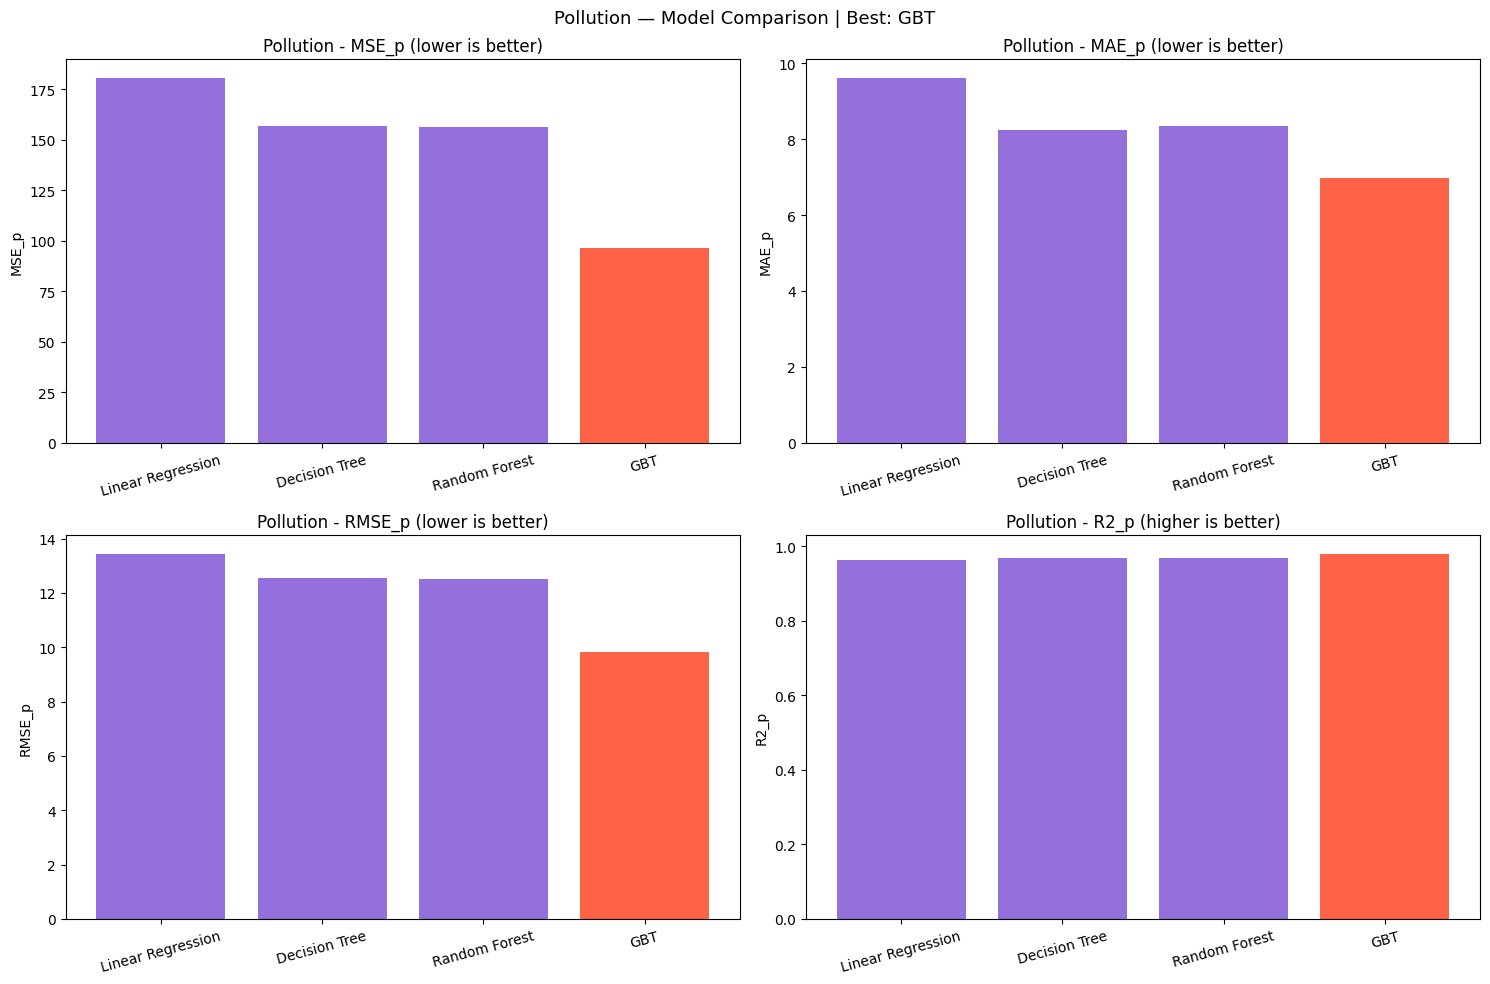

In [82]:
# Comparison Bar Chart

plot_metric_bars(results_p, best_name_p, '_p', "Pollution", "mediumpurple")

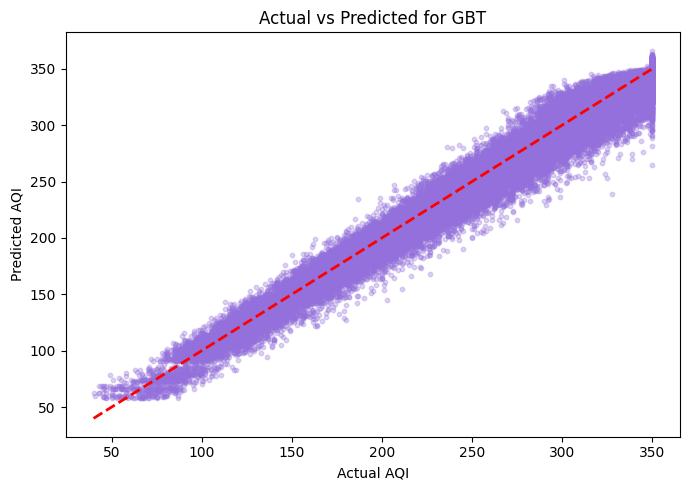

In [83]:
# Actual vs Predicted (Best Model)

plot_actual_vs_pred(results_p, best_name_p, "Actual AQI", "Predicted AQI", "mediumpurple")

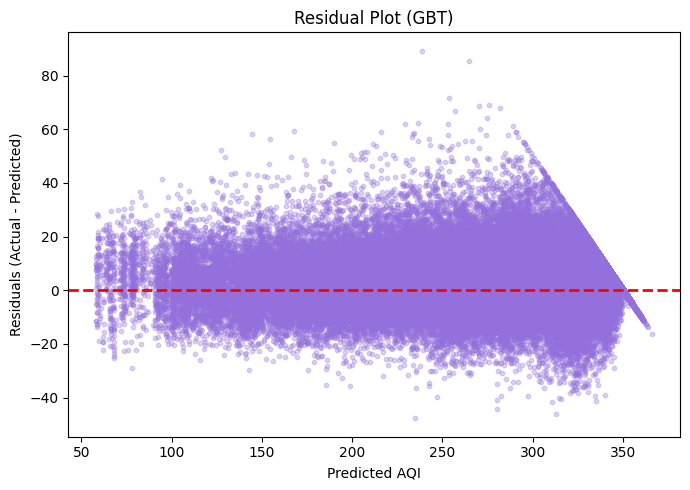

In [84]:
# Residual Plot

plot_residuals(results_p, best_name_p, "Predicted AQI", "mediumpurple")

28
28
28


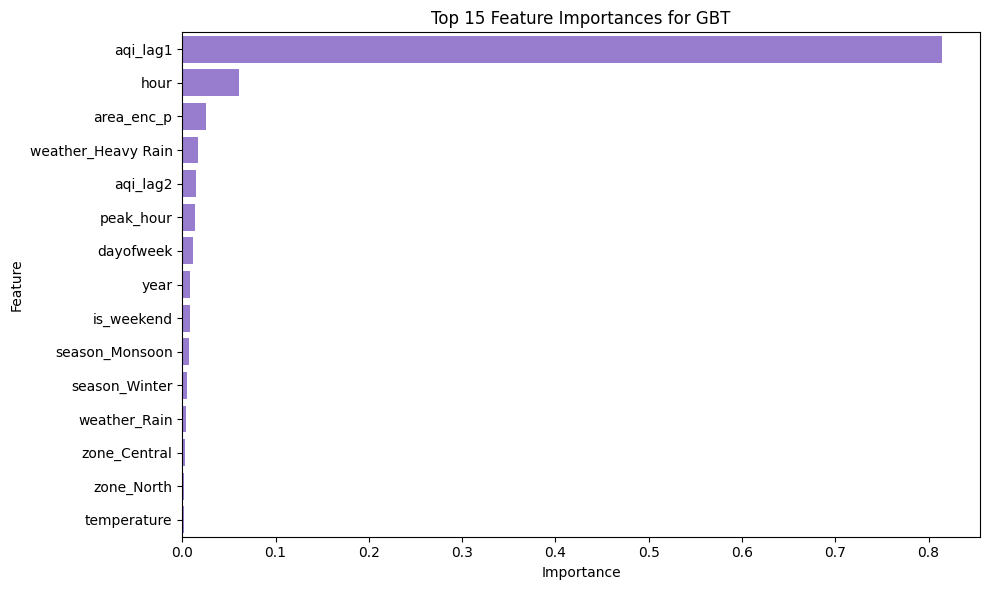

In [85]:
# Feature Importance (Best Model if supported)
expanded_feature_names_p = []

# Numeric features
expanded_feature_names_p.extend(num_cols_p)

# OHE features
for col_name in cat_cols_p:
    labels = enc_model_p.stages[
        cat_cols_p.index(col_name)
    ].labels
    expanded_feature_names_p.extend(
        [f"{col_name}_{lbl}" for lbl in labels]
    )

# Already encoded
expanded_feature_names_p.extend(already_enc_p)
print(len(expanded_feature_names_p))
print(len(expanded_feature_names_p))
# Extract the classifier stage from the pipeline
rf_model = best_model_p.stages[-1]   # assuming last stage is your RandomForest/GBT/DecisionTree

# Now safely access feature importances
print(len(rf_model.featureImportances.toArray()))

plot_feature_importance(
    rf_model,                       # pass the classifier, not the pipeline
    expanded_feature_names_p,
    best_name_p,
    "mediumpurple"
)


**Save the best model**

In [86]:
# Create subfolder for pollution models
pollution_model_dir = f"{MODELS_DIR}/pollution_models"
os.makedirs(pollution_model_dir, exist_ok=True)

# Remove old Spark model folders if they exist
model_paths = [
    f"{pollution_model_dir}/best_model",
    f"{pollution_model_dir}/encoder_model",
    f"{pollution_model_dir}/scaler_model"
]

for path in model_paths:
    if os.path.exists(path):
        shutil.rmtree(path)

# Save Spark models separately
best_model_p.write().overwrite().save(
    f"{pollution_model_dir}/best_model"
)
enc_model_p.write().overwrite().save(
    f"{pollution_model_dir}/encoder_model"
)
sc_model_p.write().overwrite().save(
    f"{pollution_model_dir}/scaler_model"
)

# Convert Spark DataFrame to pandas before saving
area_freq_pd_p = area_freq_p.toPandas()

# Save metadata as pickle
pollution_metadata = {
    'best_name_p': best_name_p,
    'num_cols_p': num_cols_p,
    'cat_cols_p': cat_cols_p,
    'already_encoded_p': already_enc_p,
    'ohe_cols_p': ohe_cols_p,
    'final_feature_cols_p': all_feature_cols_p,
    'area_freq_p': area_freq_pd_p,
    'best_model_path':
        f"{pollution_model_dir}/best_model",
    'encoder_model_path':
        f"{pollution_model_dir}/encoder_model",
    'scaler_model_path':
        f"{pollution_model_dir}/scaler_model",
    'mae_p':          results_p[best_name_p]['MAE'],
    'rmse_p':         results_p[best_name_p]['RMSE'],
    'r2_p':           results_p[best_name_p]['R2 score'],
    'trained_rows_p': train_p.count()
}

joblib.dump(
    pollution_metadata,
    f"{MODELS_DIR}/pollution_metadata.pkl"
)

print(f"✅ Pollution model saved successfully")
print(f"✅ Metadata → {MODELS_DIR}/pollution_metadata.pkl")

# Release cache after save
pollution.unpersist()
train_p.unpersist()
test_p.unpersist()

✅ Pollution model saved successfully
✅ Metadata → saved_models/pollution_metadata.pkl


DataFrame[zone: string, AQI: double, weather: string, temperature: double, humidity: double, is_weekend: double, is_it_hub: double, season: string, hour: double, day: double, dayofweek: double, month: double, year: double, temp_humidity_interaction: double, temp_inversion_risk: double, peak_hour: int, low_humidity_flag: int, aqi_lag1: double, aqi_lag2: double, area_enc_p: double, zone_idx: double, weather_idx: double, season_idx: double, zone_ohe: vector, weather_ohe: vector, season_ohe: vector, num_raw_p: vector, num_scaled_p: vector, features: vector]

In [87]:
# FINAL SUMMARY: All Datasets & Models

print("=" * 80)
print("            FINAL SUMMARY — ALL DATASETS & MODELS")
print("=" * 80)
print(f"{'Dataset':<12} {'Model':<28} {'MSE':>14} {'MAE':>10} {'RMSE':>10} {'R²':>8}")
print("-" * 80)

for ds_name, res, r2_key, mse_key, mae_key, rmse_key, best_name in [
    ('Traffic',   results_t, 'R2 score', 'MSE', 'MAE', 'RMSE', best_name_t),
    ('Energy',    results_e, 'R2 score', 'MSE', 'MAE', 'RMSE', best_name_e),
    ('Pollution', results_p, 'R2 score', 'MSE', 'MAE', 'RMSE', best_name_p),
]:
    for name in res:
        flag = ' ✅' if name == best_name else ''
        r = res[name]
        print(f"{ds_name:<12} {name:<28} "
              f"{r[mse_key]:>14.4f} {r[mae_key]:>10.4f} {r[rmse_key]:>10.4f} {r[r2_key]:8.4f}{flag}")
    print("-" * 80)

print(f"\n  Traffic   best → {best_name_t}")
print(f"  Energy    best → {best_name_e}")
print(f"  Pollution best → {best_name_p}")

print("\nSaved Model Locations:")
print(f"Traffic   → {MODELS_DIR}/traffic_models")
print(f"Energy    → {MODELS_DIR}/energy_models")
print(f"Pollution → {MODELS_DIR}/pollution_models")

print("=" * 80)

            FINAL SUMMARY — ALL DATASETS & MODELS
Dataset      Model                                   MSE        MAE       RMSE       R²
--------------------------------------------------------------------------------
Traffic      Linear Regression                46099.8337   163.7255   214.7087   0.9207
Traffic      Decision Tree                    10513.8222    60.0426   102.5369   0.9819 ✅
Traffic      Random Forest                    11339.9989    69.0305   106.4894   0.9805
Traffic      GBT                              10947.2064    69.9438   104.6289   0.9812
--------------------------------------------------------------------------------
Energy       Linear Regression               239179.4783   306.3474   489.0598   0.9589
Energy       Decision Tree                   225056.1582   286.8125   474.4008   0.9613
Energy       Random Forest                   207300.9015   279.8857   455.3031   0.9644
Energy       GBT                             165878.1166   236.8137   407.2814   0

In [88]:
spark.stop()
print("Spark session stopped")

Spark session stopped
